In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
#Phase 1: Data Collection & EDA
# Step 1: Data Import and Preprocessing
df = pd.read_csv("Global_Pollution_Analysis.csv")
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [3]:
df.isnull().sum()

Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

In [4]:
le = LabelEncoder()
df['Country'] = le.fit_transform(df['Country'])


In [5]:
scaler = StandardScaler()
cols_to_scale = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [6]:
#Step 2: Exploratory Data Analysis (EDA)
df.describe()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,88.575000,2009.335000,7.549517e-17,-3.552714e-16,2.486900e-16,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,49.924107,5.765325,1.002509e+00,1.002509e+00,1.002509e+00,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,0.000000,2000.000000,-1.947928e+00,-1.768540e+00,-1.650240e+00,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,45.750000,2004.000000,-6.823730e-01,-8.536990e-01,-8.989775e-01,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,90.500000,2010.000000,4.122312e-02,-5.821733e-02,5.332837e-02,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,131.000000,2014.000000,8.489305e-01,8.935479e-01,8.265007e-01,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,174.000000,2019.000000,1.753566e+00,1.775151e+00,1.837213e+00,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


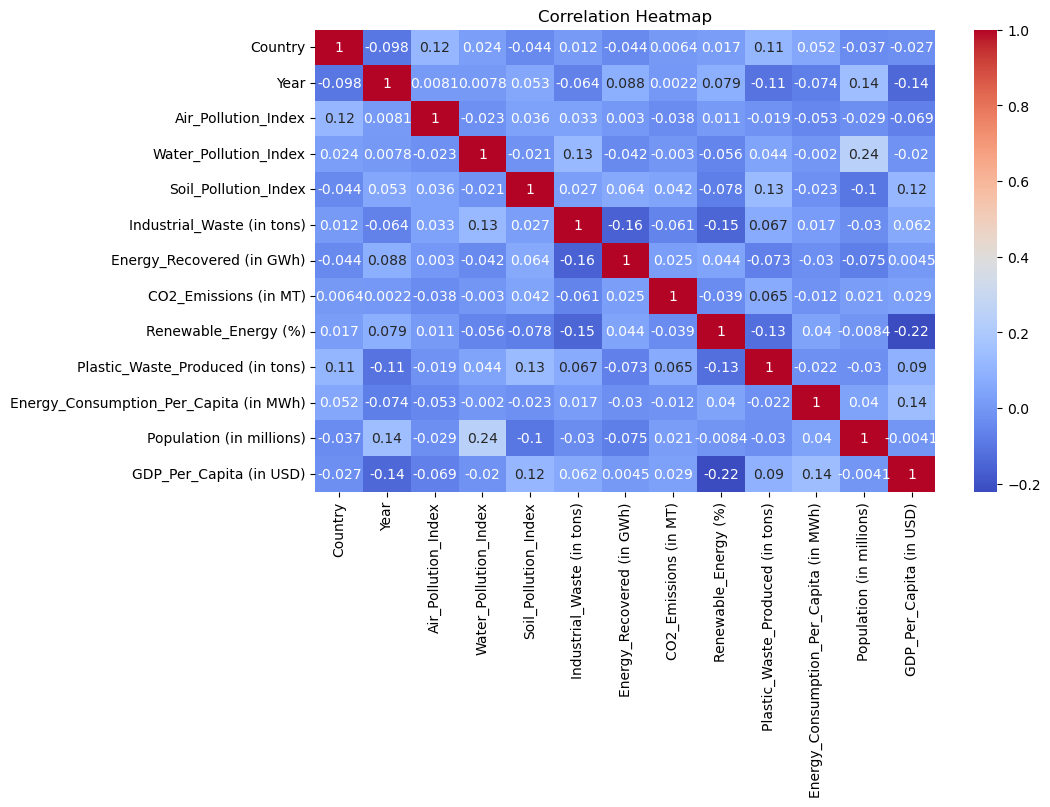

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

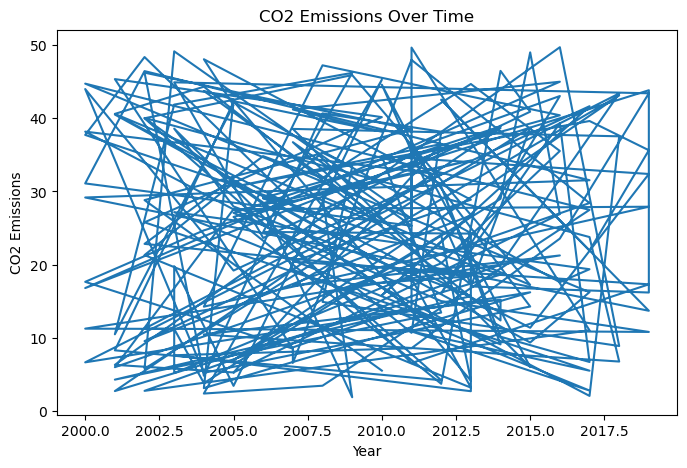

In [8]:
plt.figure(figsize=(8,5))
plt.plot(df['Year'], df['CO2_Emissions (in MT)'])
plt.title("CO2 Emissions Over Time")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions")
plt.show()

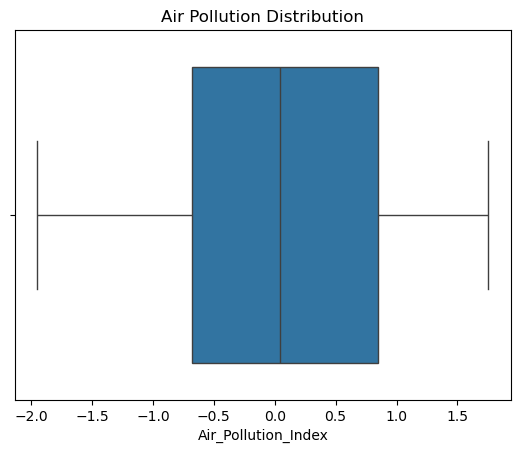

In [9]:
sns.boxplot(x=df['Air_Pollution_Index'])
plt.title("Air Pollution Distribution")
plt.show()

In [17]:
#Phase 2: Predictive Modeling
X = df[['Air_Pollution_Index', 'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)']]
y = df['Energy_Recovered (in GWh)']
X_train, X_test, y_train, y_test_lr = train_test_split(X, y, test_size=0.2)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [11]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: -0.032771956473791386
MSE: 23572.366492288314
MAE: 136.52945303969506


In [18]:

df['Pollution_Level'] = pd.cut(df['Air_Pollution_Index'],
                              bins=3,
                              labels=['Low', 'Medium', 'High'])

df['Pollution_Level'] = LabelEncoder().fit_transform(df['Pollution_Level'])

X = df[['Air_Pollution_Index', 'CO2_Emissions (in MT)']]
y = df['Pollution_Level']

X_train, X_test, y_train, y_test_log = train_test_split(X, y, test_size=0.2)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



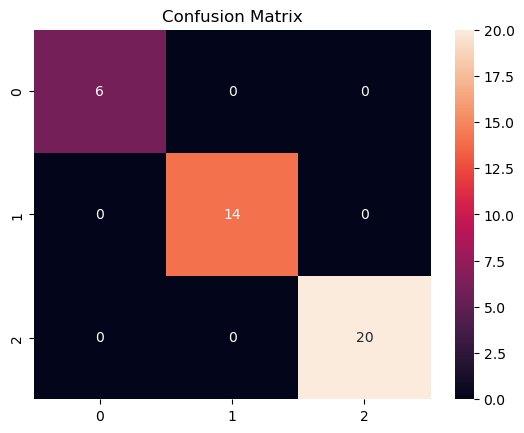

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [19]:
#Phase 3: Reporting & Insights
# Linear Regression Evaluation

print("🔹 Linear Regression Performance:")
print("R2 Score:", r2_score(y_test_lr, y_pred_lr))
print("MSE:", mean_squared_error(y_test_lr, y_pred_lr))
print("MAE:", mean_absolute_error(y_test_lr, y_pred_lr))

🔹 Linear Regression Performance:
R2 Score: -0.03937319685452412
MSE: 23209.15459780384
MAE: 136.65435311252358


In [20]:
# Logistic Regression Evaluation

print("\n🔹 Logistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test_log, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test_log, y_pred_log))


🔹 Logistic Regression Performance:
Accuracy: 0.975

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       1.00      1.00      1.00         8
           2       0.94      1.00      0.97        17

    accuracy                           0.97        40
   macro avg       0.98      0.98      0.98        40
weighted avg       0.98      0.97      0.97        40



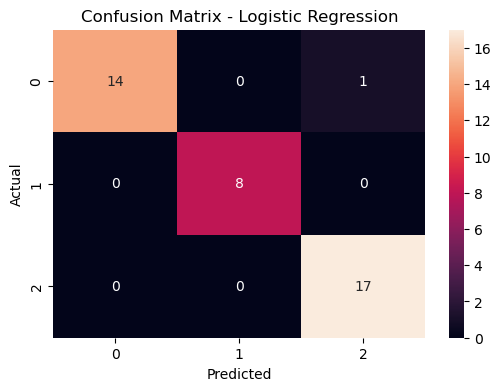

In [21]:
# Confusion Matrix Visualization

cm = confusion_matrix(y_test_log, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
# Step 7: Actionable Insights
insights = df.groupby('Pollution_Level')['Energy_Recovered (in GWh)'].mean()
print(insights)

Pollution_Level
0    262.134179
1    261.010000
2    258.776905
Name: Energy_Recovered (in GWh), dtype: float64


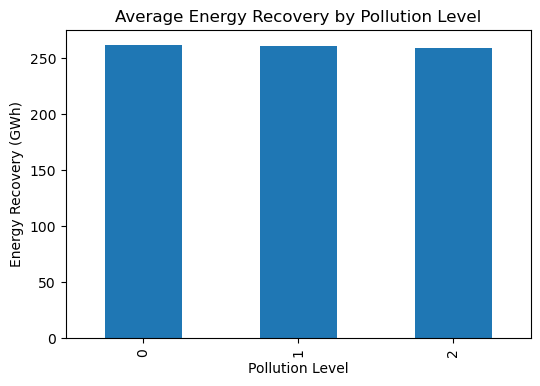

In [25]:
plt.figure(figsize=(6,4))
insights.plot(kind='bar')
plt.title("Average Energy Recovery by Pollution Level")
plt.xlabel("Pollution Level")
plt.ylabel("Energy Recovery (GWh)")
plt.show()

In [30]:
# Countries with high pollution but also high energy recovery potential

top_countries = df.sort_values(by='Energy_Recovered (in GWh)', ascending=False).head(10)

print("Top Countries with High Energy Recovery Potential:")
print(top_countries[['Country', 'Pollution_Level', 'Energy_Recovered (in GWh)']])

Top Countries with High Energy Recovery Potential:
     Country  Pollution_Level  Energy_Recovered (in GWh)
7         31                2                     499.98
1        147                1                     498.04
8        156                0                     495.28
60        54                0                     493.12
111       72                2                     492.08
2        136                1                     489.51
153       98                2                     487.84
49        85                2                     486.72
79        30                1                     484.72
115      157                2                     481.67
